In [1]:
import csv
import math
import os

import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
path = "results_sailing.csv"  # single input file
outdir = "plots"
title = "Experiment MCTS.1 - Sailing"  # optional title override

In [3]:
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",

    # Embed fonts as TrueType (selectable/searchable)
    "pdf.fonttype": 42,
    "ps.fonttype": 42,

    # sizes (tune if you want)
    "axes.titlesize": 23,
    "axes.labelsize": 18,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    # Times-like fonts, matching paper
    "text.latex.preamble": r"""
        \usepackage{newtxtext}
        \usepackage{newtxmath}
    """,
})

In [4]:
rows = []
with open(path, "r", newline="") as f:
    reader = csv.DictReader(f)
    required = {"env", "algorithm", "run", "trial", "mc_mean", "mc_stddev"}
    missing = required - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f"{path}: missing columns: {missing}")
    for r in reader:
        rows.append({
            "env": r["env"],
            "algorithm": r["algorithm"],
            "run": int(r["run"]),
            "trial": int(r["trial"]),
            "mc_mean": float(r["mc_mean"]),
            "mc_stddev": float(r["mc_stddev"]),
        })

In [5]:
algos = ["UCT", "MENTS", "RENTS", "TENTS", "DENTS", "BTS", "VarDE"]
colors = ["#1f77b4", "#d62728", "#9467bd", "#8c564b", "#ff27be", "#ff7f0e", "#2ca02c"]

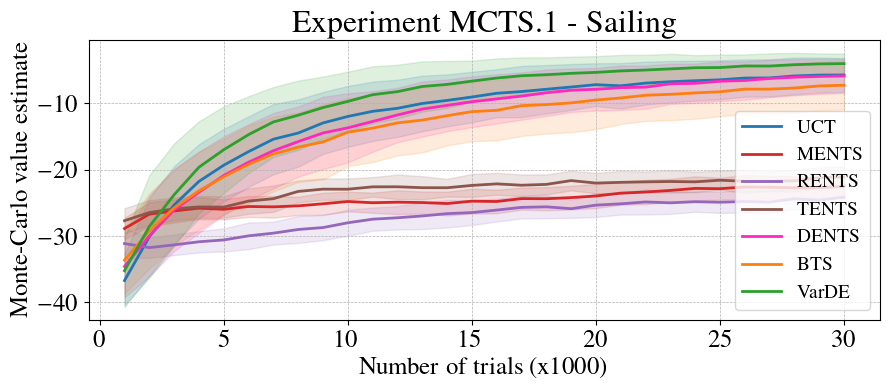

In [6]:
os.makedirs(outdir, exist_ok=True)
outputs = []

fig, ax = plt.subplots(figsize=(9, 4))

for alg in algos:
    trials = sorted(set(r["trial"] for r in rows if r["algorithm"] == alg))
    xs = [t / 1000.0 for t in trials]  # paper uses x1000

    ys = []
    yerr = []
    for t in trials:
        rows_t = [r for r in rows if r["algorithm"] == alg and r["trial"] == t]
        means = [rr["mc_mean"] for rr in rows_t]
        if len(means) >= 2:
            m = sum(means) / len(means)
            s = math.sqrt(sum((x - m) ** 2 for x in means) / (len(means) - 1))
            ys.append(m)
            yerr.append(s)
        else:
            ys.append(rows_t[0]["mc_mean"])
            yerr.append(rows_t[0]["mc_stddev"])

    color = colors.pop(0) if colors else None
    label = alg
    ax.plot(xs, ys, linewidth=2.0, label=label, color=color)

    lower = [y - e for y, e in zip(ys, yerr)]
    upper = [y + e for y, e in zip(ys, yerr)]
    ax.fill_between(xs, lower, upper, alpha=0.15, color=color)

ax.set_xlabel("Number of trials (x1000)")
ax.set_ylabel("Monte-Carlo value estimate")

ax.set_title(title)

ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend(loc="lower right", frameon=True, framealpha=0.8)

out_path = os.path.join(outdir, f"{rows[0]['env']}.pdf")
fig.tight_layout()
fig.savefig(out_path)